# P3 Using Cartopy for Mapping
## SEA4001W: Intro to Data Science  (Prof Marcello Vichi)
### Vivienne Banks - BNKVIV001
#### 15 March 2026
---

### Import Modules

In [1]:
# Remove runtime warnings (Mac has a lot of these).
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Import plotting and mapping modules
import numpy as np 
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
geolocator = Nominatim(user_agent='educational')

---

### Task 1
The Antarctic continent and the Southern Ocean starting from 60°S.

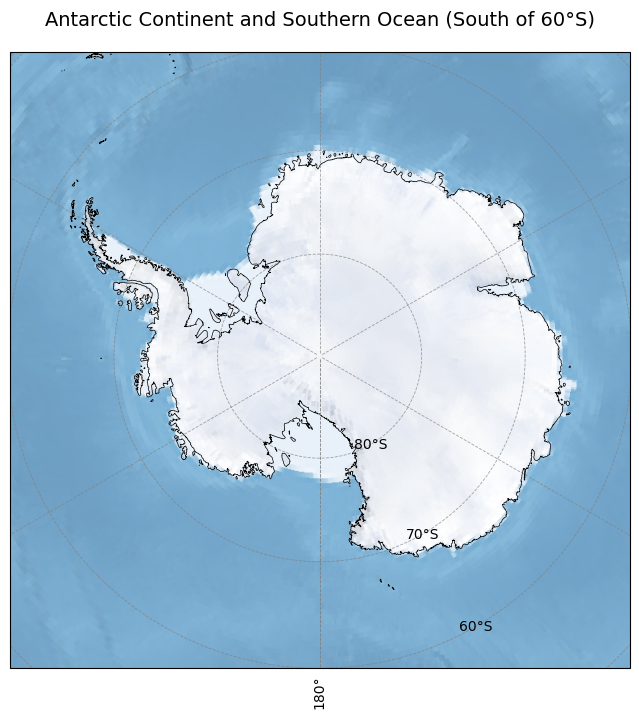

In [2]:
# Creating the base figure with size 8x8 inches
fig = plt.figure(figsize=(8,8))

# Set projection to SouthPolarStereo
ax = plt.axes(projection=ccrs.SouthPolarStereo())

# Set the extent to cover the Southern Ocean from 60ºS
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

## Add features to the figure

ax.stock_img() # Add a shaded background image of Earth (land, ocean, and terrain)
ax.coastlines(resolution='10m', linewidth=0.5) # Add coastline detail to a resolution of 10m


# Add gridlines
gl = ax.gridlines(draw_labels=True,linewidth=0.6, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False


# Add a title
ax.set_title("Antarctic Continent and Southern Ocean (South of 60°S)", fontsize=14, pad=20)

# Show the figure
plt.show()

**Figure 1:** Map of Antarctica and the Southern Ocean south of 60ºS.

This map uses the South Polar Stereographic projection, which is commonly used for polar regions because it minimizes distortion near the poles. This projection is well suited for visualising the Antarctic continent and the surrounding Southern Ocean as allows Antarctica to be displayed in a centred, circular layout with minimal spatial distortion.

---

### Task 2
The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo.

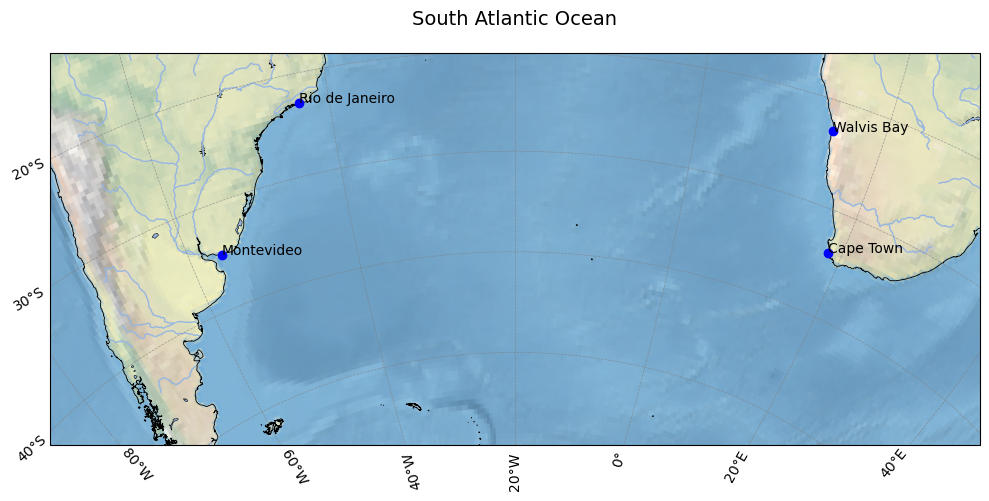

In [4]:
# Create the base figure with size 12x6 inches
plt.figure(figsize=(12, 6))

# Set the extent and centre of the map
extent = [-70, 30, -50, -20] 
central_lon = np.mean(extent[:2])
central_lat = np.mean(extent[2:])
# Set projection to AzimulthalEquidistant
ax = plt.axes(projection=ccrs.AzimuthalEquidistant(central_lon, central_lat)) 
ax.set_extent(extent, crs=ccrs.PlateCarree())


# Add geographic features
ax.stock_img() # Add a shaded background image of Earth (land, ocean, and terrain)
ax.add_feature(cartopy.feature.LAKES, edgecolor='black', linewidth=0.4) # Add lakes
ax.add_feature(cartopy.feature.RIVERS) # Add Rivers
ax.coastlines(resolution='10m', linewidth=0.6) # Add coastlines

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', color='gray', alpha=0.7)
gl.top_labels = False
gl.right_labels = False


# Add place names to the map
places = ["Walvis Bay", "Cape Town", "Rio de Janeiro", "Montevideo"]

# Retrieve address information
address=[]
for p in places:
    loc = geolocator.geocode(p,language="en")
    address.append(loc)
    
# Use address information to place the names at the correct locations
for p in range(len(places)):
    ax.text(address[p].longitude,address[p].latitude,places[p],transform=ccrs.Geodetic())
    ax.plot(address[p].longitude, address[p].latitude, marker='o', color='blue', transform=ccrs.PlateCarree())


# Add a title
ax.set_title("South Atlantic Ocean", fontsize=14, pad=20)

# Show the figure
plt.show()

**Figure 2:** Map of the Southern Ocean between 20 and 50ºS showing Walvis Bay, Cape Town, Rio de Janeiro and Montevideo.

This map uses the Azimuthal Equidistant projection, which preserves true distances from the centre of the map. By centring the projection over the South Atlantic, distortion across the region is reduced and the spatial relationships between the coastal locations are clearly represented.

---

### Task 3
A series of 3 panels showing the use of different coastline resolutions from the GSHHG database in a map of False Bay. Display the coarse, intermediate and full resolution.

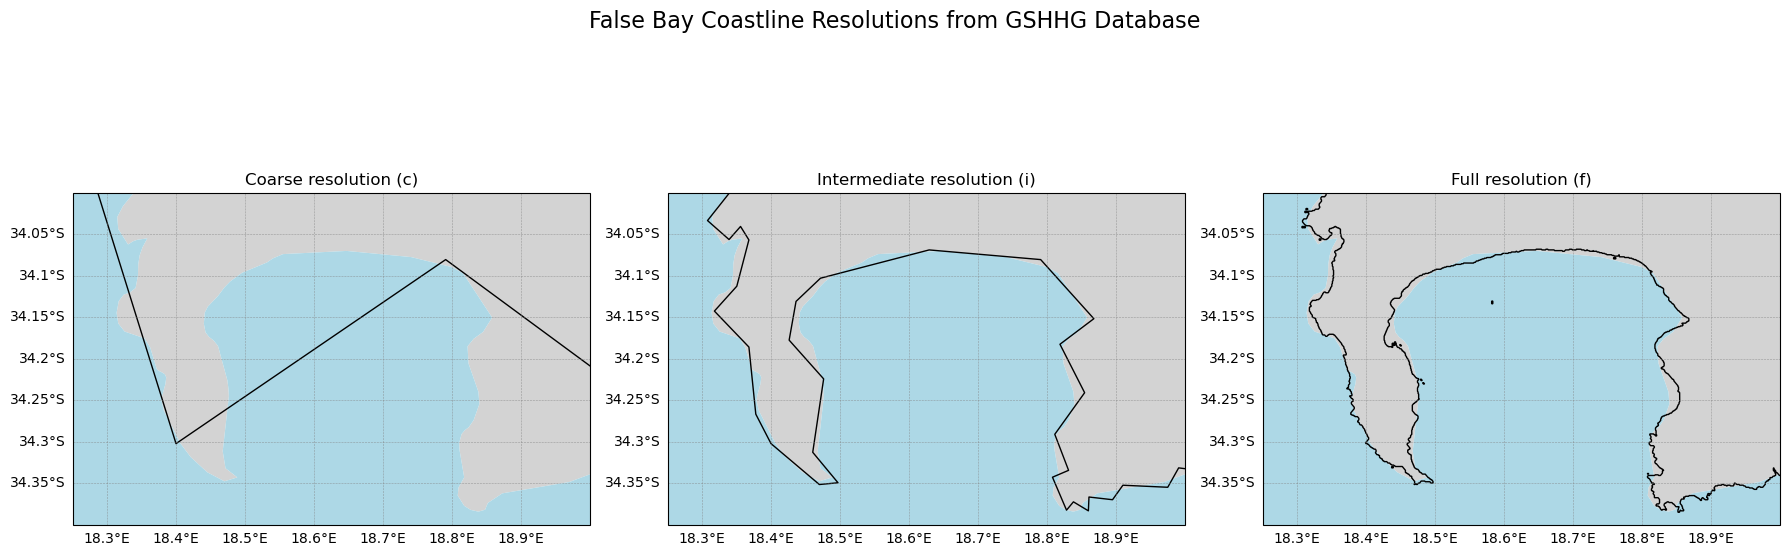

In [5]:
# Set the extent to cover False Bay region
extent = [18.25, 19, -34.4, -34]

# Set up figure with 3 panels side by side
fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.Mercator()})

# Titles and resolutions for the 3 panels
resolutions = [('c', 'Coarse'), ('i', 'Intermediate'), ('f', 'Full')]

# Loop to add features and the correct resolution to each subplot.
for ax, (scale, title) in zip(axs, resolutions):
    # Set extent to False Bay region
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgray') # Land features
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue') # Ocean features
    
    # Add coastlines from GSHHG dataset at specified resolution
    coast = cfeature.GSHHSFeature(scale=scale, facecolor='none')
    ax.add_feature(coast, edgecolor='black') 
    
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.7, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    # Add a title for each subplot
    ax.set_title(f'{title} resolution ({scale})', fontsize=12)

# Add a main title for all subplots
plt.suptitle('False Bay Coastline Resolutions from GSHHG Database', fontsize=16, y=1.05)

# Show the figure with a nice layout
plt.tight_layout()
plt.show()

**Figure 3** Coastline of False Bay displayed using three different resolutions from the GSHHG database. From left to right the coastline resolution increases from coarse to intermediate to full.

These maps use the Mercator projection, which is suitable for small regional areas because distortion is minimal over short distances. The comparison highlights how increasing resolution from the GSHHG dataset captures progressively finer details of the coastline geometry.

---